# HCP Brain Network — Node Perturbation Analysis

This notebook simulates **node removal** and **node addition** on the HCP structural connectivity network, targeting key nodes identified by centrality and role metrics.

Sections:
1. **Setup** — load SC data, rebuild graphs, re-identify key nodes
2. **Node Removal** — targeted (hub/broker/bridge) vs random; track network collapse
3. **Node Addition** — hub-like, random, and bridge-type additions; track integration gains
4. **Cascade Failure Simulation** — failure propagates to neighbours
5. **Summary** — before/after comparison of all metrics

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from scipy import stats
from copy import deepcopy

from enigmatoolbox.datasets import load_sc

np.random.seed(42)
%matplotlib inline
print('Imports successful.')

Imports successful.


---
## Section 0: Setup — Load Data & Identify Key Nodes

In [13]:
# ── Load HCP SC ───────────────────────────────────────────────────────────────
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()
n = sc_ctx.shape[0]   # 68
A_bin = (sc_ctx > 0).astype(float)

G_w  = nx.from_numpy_array(sc_ctx)
G_uw = nx.from_numpy_array(A_bin)

# Inverse-weight graph for distance-based metrics
G_dist = G_w.copy()
for u, v, d in G_dist.edges(data=True):
    d['distance'] = 1.0 / (d['weight'] + 1e-9)

print(f'Loaded SC: {n} cortical regions')

Loaded SC: 68 cortical regions


In [14]:
# ── Compute centrality measures ───────────────────────────────────────────────
strength    = np.array([d for _, d in G_w.degree(weight='weight')])
degree_bin  = np.array([d for _, d in G_uw.degree()])
betweenness = np.array(list(nx.betweenness_centrality(G_dist, weight='distance', normalized=True).values()))
eigenvec    = np.array(list(nx.eigenvector_centrality_numpy(G_w, weight='weight').values()))
closeness   = np.array(list(nx.closeness_centrality(G_dist, distance='distance').values()))

z_str = stats.zscore(strength)
z_btw = stats.zscore(betweenness)
z_eig = stats.zscore(eigenvec)
z_deg = stats.zscore(degree_bin)

# ── Classify roles ────────────────────────────────────────────────────────────
is_hub    = (z_str > 1.0) & (z_eig > 1.0)
is_broker = (z_btw > 1.0) & ~is_hub
is_bridge = (z_btw > 0.5) & (z_deg < 0.0) & ~is_hub & ~is_broker

hub_nodes    = np.where(is_hub)[0]
broker_nodes = np.where(is_broker)[0]
bridge_nodes = np.where(is_bridge)[0]

print(f'Hubs    ({len(hub_nodes)}): {[sc_ctx_labels[i] for i in hub_nodes]}')
print(f'Brokers ({len(broker_nodes)}): {[sc_ctx_labels[i] for i in broker_nodes]}')
print(f'Bridges ({len(bridge_nodes)}): {[sc_ctx_labels[i] for i in bridge_nodes]}')

Hubs    (9): [np.str_('L_precuneus'), np.str_('L_rostralmiddlefrontal'), np.str_('L_superiorfrontal'), np.str_('L_superiorparietal'), np.str_('L_insula'), np.str_('R_precuneus'), np.str_('R_superiorfrontal'), np.str_('R_superiorparietal'), np.str_('R_insula')]
Brokers (0): []
Bridges (0): []


In [15]:
# ── Helper: compute network metrics from adjacency matrix ─────────────────────
def network_metrics(A, labels=None):
    """Return dict of key metrics for a weighted adjacency matrix."""
    m = {}
    n_nodes = A.shape[0]
    A_b = (A > 0).astype(float)
    G   = nx.from_numpy_array(A_b)
    Gw  = nx.from_numpy_array(A)

    # Basic
    m['n_nodes']  = n_nodes
    m['n_edges']  = int(A_b.sum() / 2)
    m['density']  = m['n_edges'] / (n_nodes * (n_nodes - 1) / 2)

    # Connectivity
    lcc = max(nx.connected_components(G), key=len)
    m['lcc_size']    = len(lcc) / n_nodes
    m['n_components'] = nx.number_connected_components(G)

    # Spectral
    eigs = np.linalg.eigvalsh(A_b)
    m['lambda1']  = eigs.max()
    m['tau']      = 1.0 / eigs.max() if eigs.max() > 0 else np.inf

    # Path-based (only on LCC)
    G_lcc = G.subgraph(lcc).copy()
    if len(G_lcc) > 1:
        m['avg_path']   = nx.average_shortest_path_length(G_lcc)
        m['global_eff'] = nx.global_efficiency(G_lcc)
    else:
        m['avg_path']   = np.inf
        m['global_eff'] = 0.0

    # Clustering
    m['avg_clustering'] = nx.average_clustering(G)

    # Weighted strength
    m['mean_strength'] = A.sum(axis=1).mean()
    m['total_strength'] = A.sum()

    return m

# Baseline metrics
baseline = network_metrics(sc_ctx)
print('── Baseline Network Metrics ─────────────────────')
for k, v in baseline.items():
    print(f'  {k:<20}: {v:.4f}' if isinstance(v, float) else f'  {k:<20}: {v}')

── Baseline Network Metrics ─────────────────────
  n_nodes             : 68
  n_edges             : 697
  density             : 0.3060
  lcc_size            : 1.0000
  n_components        : 1
  lambda1             : 23.0335
  tau                 : 0.0434
  avg_path            : 1.7291
  global_eff          : 0.6471
  avg_clustering      : 0.5616
  mean_strength       : 151.8052
  total_strength      : 10322.7553


---
## Section 1: Node Removal Simulation

We remove nodes one at a time under four strategies and track how the network degrades:

| Strategy | Description | Brain analogy |
|---|---|---|
| **Hub targeted** | Remove highest-strength nodes first | Focal lesion in integration hubs |
| **Broker targeted** | Remove highest-betweenness nodes first | Disruption of inter-module gating |
| **Bridge targeted** | Remove bridge (gatekeeper) nodes first | Disconnection of weak communities |
| **Random** | Remove nodes in random order (×20 repeats) | Diffuse damage / random neuron loss |

In [16]:
# ── Node removal simulation ────────────────────────────────────────────────────
def simulate_removal(A, removal_order, metric_keys):
    """Remove nodes in order, collect metrics at each step."""
    records = []
    remaining = list(range(A.shape[0]))
    for step, node in enumerate(removal_order):
        remaining = [r for r in remaining if r != node]
        if len(remaining) < 3:
            break
        sub = A[np.ix_(remaining, remaining)]
        m = network_metrics(sub)
        m['step'] = step + 1
        m['frac_removed'] = (step + 1) / A.shape[0]
        records.append({k: m[k] for k in metric_keys + ['step', 'frac_removed']})
    return pd.DataFrame(records)

KEYS = ['lcc_size', 'global_eff', 'lambda1', 'avg_clustering', 'n_components']

# Define removal orders
order_hub    = np.argsort(strength)[::-1]          # strongest first
order_broker = np.argsort(betweenness)[::-1]       # highest betweenness first
order_bridge = np.concatenate([                     # bridges first, then rest
    bridge_nodes[np.argsort(betweenness[bridge_nodes])[::-1]],
    np.array([i for i in np.argsort(betweenness)[::-1] if i not in bridge_nodes])
])
order_random = np.random.permutation(n)             # random baseline

print('Running removal simulations...')
df_hub    = simulate_removal(sc_ctx, order_hub,    KEYS)
df_broker = simulate_removal(sc_ctx, order_broker, KEYS)
df_bridge = simulate_removal(sc_ctx, order_bridge, KEYS)

# Random: average over 20 trials
rand_dfs = [simulate_removal(sc_ctx, np.random.permutation(n), KEYS) for _ in range(20)]
df_rand  = pd.concat(rand_dfs).groupby('frac_removed').mean().reset_index()

print('Done.')

Running removal simulations...


Done.


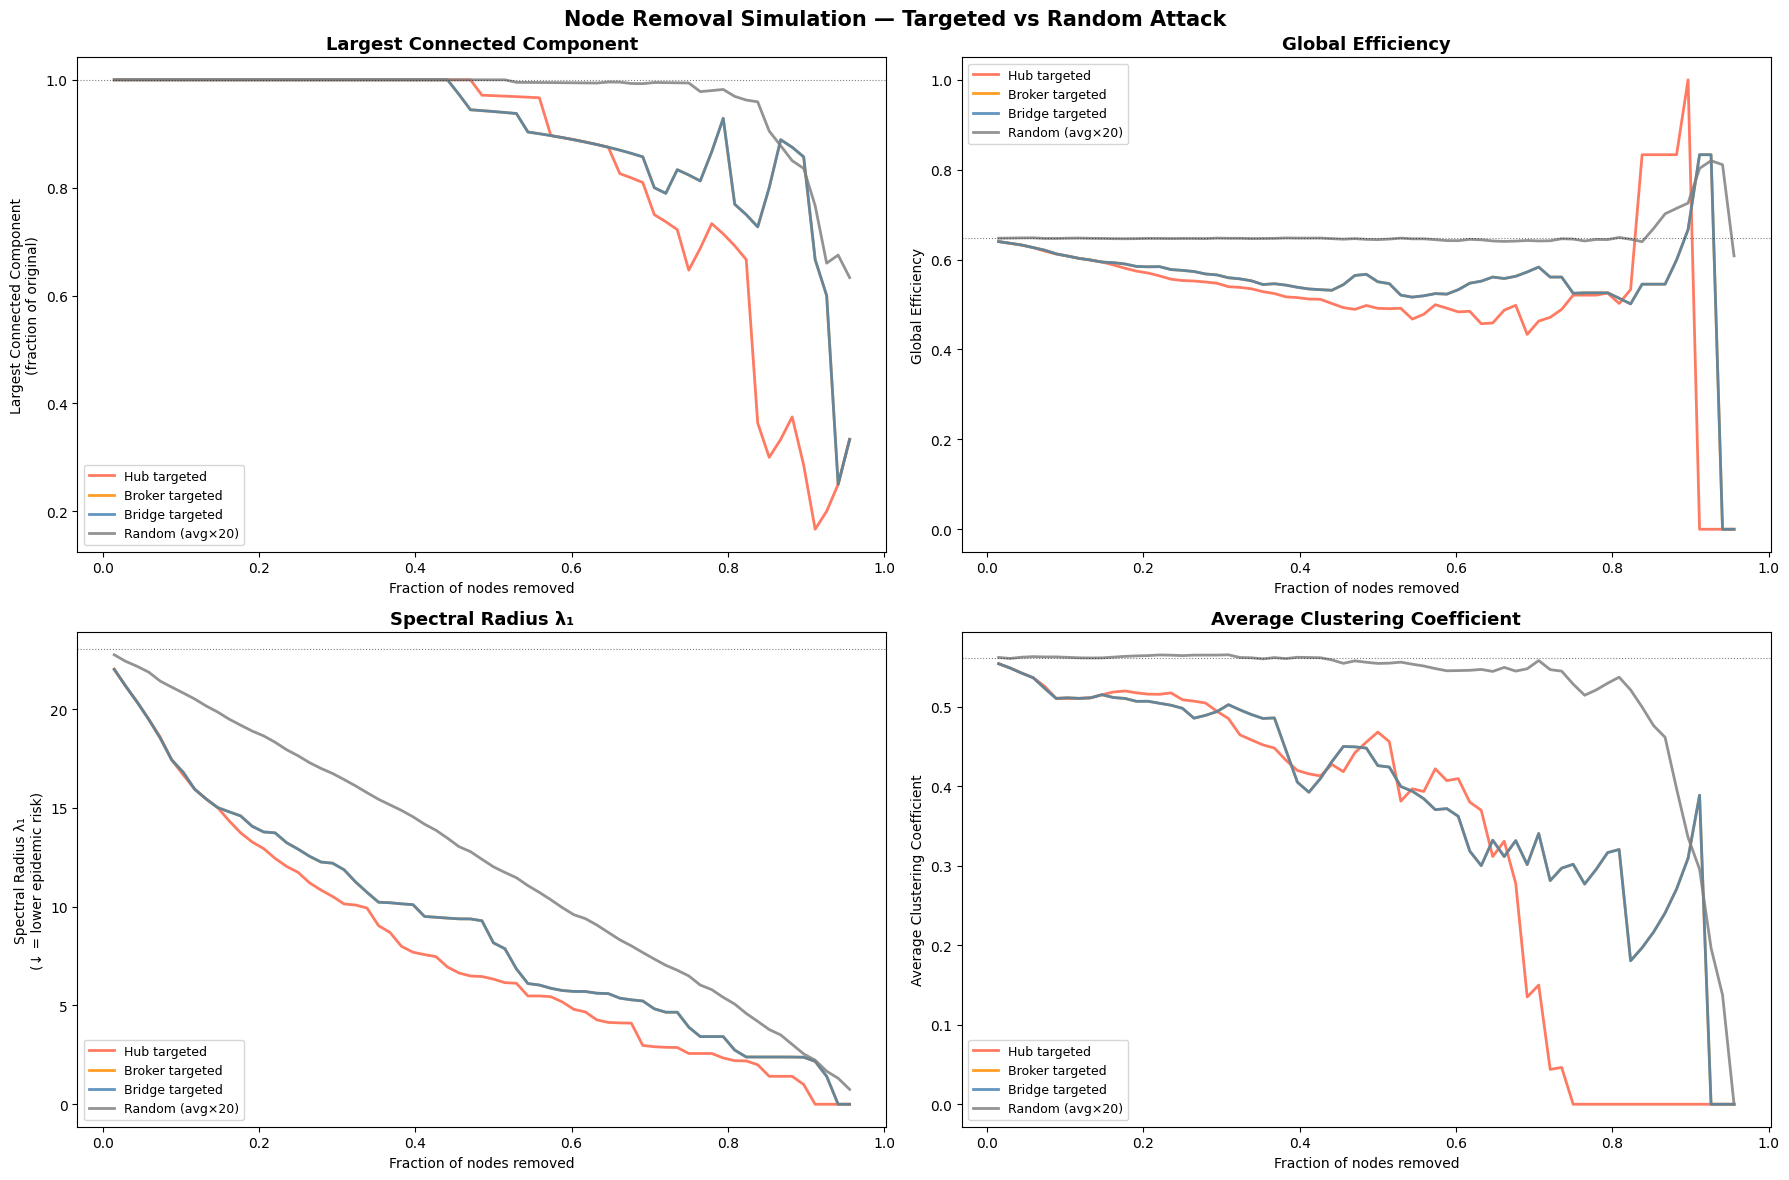


Fraction removed to reach LCC < 0.5:
  Hub targeted          : 0.8382352941176471
  Broker targeted       : 0.9411764705882353
  Bridge targeted       : 0.9411764705882353
  Random (avg×20)       : >1.0


In [17]:
# ── Plot removal curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

strategies = [
    (df_hub,    'Hub targeted',    'tomato'),
    (df_broker, 'Broker targeted', 'darkorange'),
    (df_bridge, 'Bridge targeted', 'steelblue'),
    (df_rand,   'Random (avg×20)', 'gray'),
]

metric_plot = [
    ('lcc_size',        'Largest Connected Component\n(fraction of original)', axes[0,0]),
    ('global_eff',      'Global Efficiency',                                   axes[0,1]),
    ('lambda1',         'Spectral Radius λ₁\n(↓ = lower epidemic risk)',       axes[1,0]),
    ('avg_clustering',  'Average Clustering Coefficient',                      axes[1,1]),
]

for metric, ylabel, ax in metric_plot:
    for df, label, color in strategies:
        if metric in df.columns:
            ax.plot(df['frac_removed'], df[metric], '-', color=color,
                    linewidth=2, label=label, alpha=0.85)
    ax.set_xlabel('Fraction of nodes removed')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split('\n')[0], fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.axhline(baseline.get(metric, np.nan), color='k', linewidth=0.8,
               linestyle=':', alpha=0.5, label='Baseline')

plt.suptitle('Node Removal Simulation — Targeted vs Random Attack', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_removal_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Critical fragmentation point (LCC < 0.5)
print('\nFraction removed to reach LCC < 0.5:')
for df, label, _ in strategies:
    below = df[df['lcc_size'] < 0.5]
    frac = below['frac_removed'].iloc[0] if len(below) > 0 else '>1.0'
    print(f'  {label:<22}: {frac}')

In [18]:
# ── Single node removal: immediate metric delta per key node ──────────────────
key_node_indices = np.concatenate([hub_nodes, broker_nodes, bridge_nodes])
key_node_labels  = [sc_ctx_labels[i] for i in key_node_indices]
key_node_roles   = (['Hub'] * len(hub_nodes) +
                    ['Broker'] * len(broker_nodes) +
                    ['Bridge'] * len(bridge_nodes))

delta_records = []
for node, label, role in zip(key_node_indices, key_node_labels, key_node_roles):
    remaining = [i for i in range(n) if i != node]
    sub = sc_ctx[np.ix_(remaining, remaining)]
    m   = network_metrics(sub)
    delta_records.append({
        'Region'       : label,
        'Role'         : role,
        'ΔLCC'         : m['lcc_size'] - 1.0,                       # was 100% before
        'ΔGlobal_Eff'  : m['global_eff'] - baseline['global_eff'],
        'Δλ₁'          : m['lambda1']    - baseline['lambda1'],
        'ΔClustering'  : m['avg_clustering'] - baseline['avg_clustering'],
        'Strength'     : strength[node],
        'Betweenness'  : betweenness[node],
    })

delta_df = pd.DataFrame(delta_records).sort_values('ΔGlobal_Eff')
print('Impact of single-node removal (sorted by Global Efficiency drop):')
print(delta_df[['Region','Role','ΔLCC','ΔGlobal_Eff','Δλ₁']].to_string(index=False))

Impact of single-node removal (sorted by Global Efficiency drop):
                Region Role  ΔLCC  ΔGlobal_Eff       Δλ₁
    R_superiorparietal  Hub   0.0    -0.007150 -1.016385
              R_insula  Hub   0.0    -0.005266 -0.862496
              L_insula  Hub   0.0    -0.004889 -0.974949
    L_superiorparietal  Hub   0.0    -0.004286 -0.789314
     R_superiorfrontal  Hub   0.0    -0.003532 -0.829009
     L_superiorfrontal  Hub   0.0    -0.003230 -0.755664
L_rostralmiddlefrontal  Hub   0.0    -0.002627 -0.613900
           R_precuneus  Hub   0.0    -0.002552 -0.679578
           L_precuneus  Hub   0.0    -0.001949 -0.600361


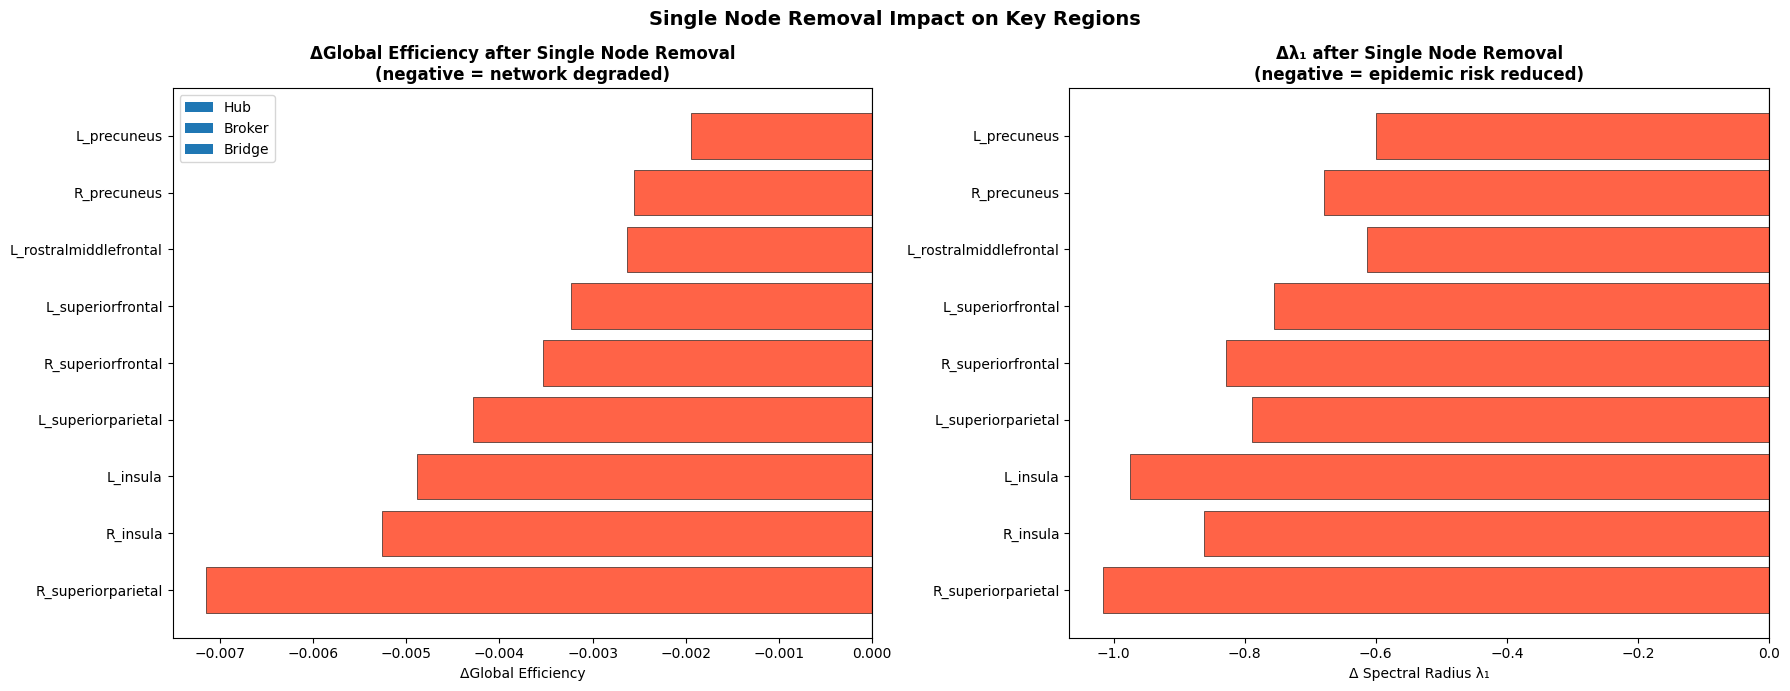

In [19]:
# ── Bar chart: impact of removing each key node ───────────────────────────────
role_colors = {'Hub': 'tomato', 'Broker': 'darkorange', 'Bridge': 'steelblue'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

delta_sorted = delta_df.sort_values('ΔGlobal_Eff')
colors = [role_colors[r] for r in delta_sorted['Role']]

axes[0].barh(delta_sorted['Region'], delta_sorted['ΔGlobal_Eff'],
             color=colors, edgecolor='k', linewidth=0.4)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_title('ΔGlobal Efficiency after Single Node Removal\n(negative = network degraded)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('ΔGlobal Efficiency')
for role, color in role_colors.items():
    axes[0].barh([], [], color=color, label=role)
axes[0].legend(fontsize=10)

axes[1].barh(delta_sorted['Region'], delta_sorted['Δλ₁'],
             color=colors, edgecolor='k', linewidth=0.4)
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title('Δλ₁ after Single Node Removal\n(negative = epidemic risk reduced)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Δ Spectral Radius λ₁')

plt.suptitle('Single Node Removal Impact on Key Regions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_single_removal_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Node Addition Simulation

We simulate adding a new synthetic node with different connectivity strategies and measure the network improvement:

| Strategy | Description | Brain analogy |
|---|---|---|
| **Hub-like** | Connect to all existing hubs with strong weights | New highly-connected region (e.g. transplant, stimulation target) |
| **Bridge-type** | Connect one node per community with moderate weight | Therapeutic reconnection across disconnected modules |
| **Random** | Connect to random subset of nodes | Undirected plasticity / noise |
| **Peripheral** | Connect only to low-degree nodes | Weak peripheral addition |

In [20]:
# ── Community detection (needed for bridge addition) ──────────────────────────
communities = list(nx.community.greedy_modularity_communities(G_uw))
community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid
n_comm = len(communities)
print(f'Communities detected: {n_comm}')

# ── Build augmented adjacency matrix ──────────────────────────────────────────
def add_node(A, new_weights):
    """Add one new node with given connection weights (length = A.shape[0])."""
    n_old = A.shape[0]
    A_new = np.zeros((n_old + 1, n_old + 1))
    A_new[:n_old, :n_old] = A
    A_new[-1, :n_old] = new_weights
    A_new[:n_old, -1] = new_weights   # symmetric
    return A_new

mean_w = sc_ctx[sc_ctx > 0].mean()
strong_w = np.percentile(sc_ctx[sc_ctx > 0], 75)

# ── Strategy 1: Hub-like ──────────────────────────────────────────────────────
w_hub = np.zeros(n)
w_hub[hub_nodes] = strong_w
A_add_hub = add_node(sc_ctx, w_hub)

# ── Strategy 2: Bridge-type (one connection per community) ───────────────────
w_bridge = np.zeros(n)
for comm in communities:
    rep = sorted(comm, key=lambda x: strength[x], reverse=True)[0]  # strongest in community
    w_bridge[rep] = mean_w
A_add_bridge = add_node(sc_ctx, w_bridge)

# ── Strategy 3: Random (k random nodes) ──────────────────────────────────────
k_rand = max(len(hub_nodes), 4)
rand_targets = np.random.choice(n, k_rand, replace=False)
w_rand = np.zeros(n)
w_rand[rand_targets] = mean_w
A_add_rand = add_node(sc_ctx, w_rand)

# ── Strategy 4: Peripheral (low-degree targets) ───────────────────────────────
low_deg = np.argsort(degree_bin)[:k_rand]
w_periph = np.zeros(n)
w_periph[low_deg] = mean_w
A_add_periph = add_node(sc_ctx, w_periph)

# ── Compare metrics ───────────────────────────────────────────────────────────
additions = [
    ('Hub-like',     A_add_hub,    w_hub),
    ('Bridge-type',  A_add_bridge, w_bridge),
    ('Random',       A_add_rand,   w_rand),
    ('Peripheral',   A_add_periph, w_periph),
]

add_records = []
for name, A_new, w_new in additions:
    m = network_metrics(A_new)
    add_records.append({
        'Strategy'      : name,
        'n_connections' : int((w_new > 0).sum()),
        'ΔGlobal_Eff'   : m['global_eff']      - baseline['global_eff'],
        'Δλ₁'           : m['lambda1']          - baseline['lambda1'],
        'ΔClustering'   : m['avg_clustering']   - baseline['avg_clustering'],
        'ΔLCC'          : m['lcc_size']          - 1.0,
        'Δ_density'     : m['density']           - baseline['density'],
        'Global_Eff'    : m['global_eff'],
        'lambda1'       : m['lambda1'],
    })

add_df = pd.DataFrame(add_records)
print(add_df[['Strategy','n_connections','ΔGlobal_Eff','Δλ₁','ΔClustering']].to_string(index=False))

Communities detected: 3
   Strategy  n_connections  ΔGlobal_Eff      Δλ₁  ΔClustering
   Hub-like              9    -0.002489 0.121422     0.000559
Bridge-type              3    -0.003981 0.014988     0.000684
     Random              9    -0.002418 0.054053    -0.009099
 Peripheral              9    -0.002204 0.011042    -0.029191


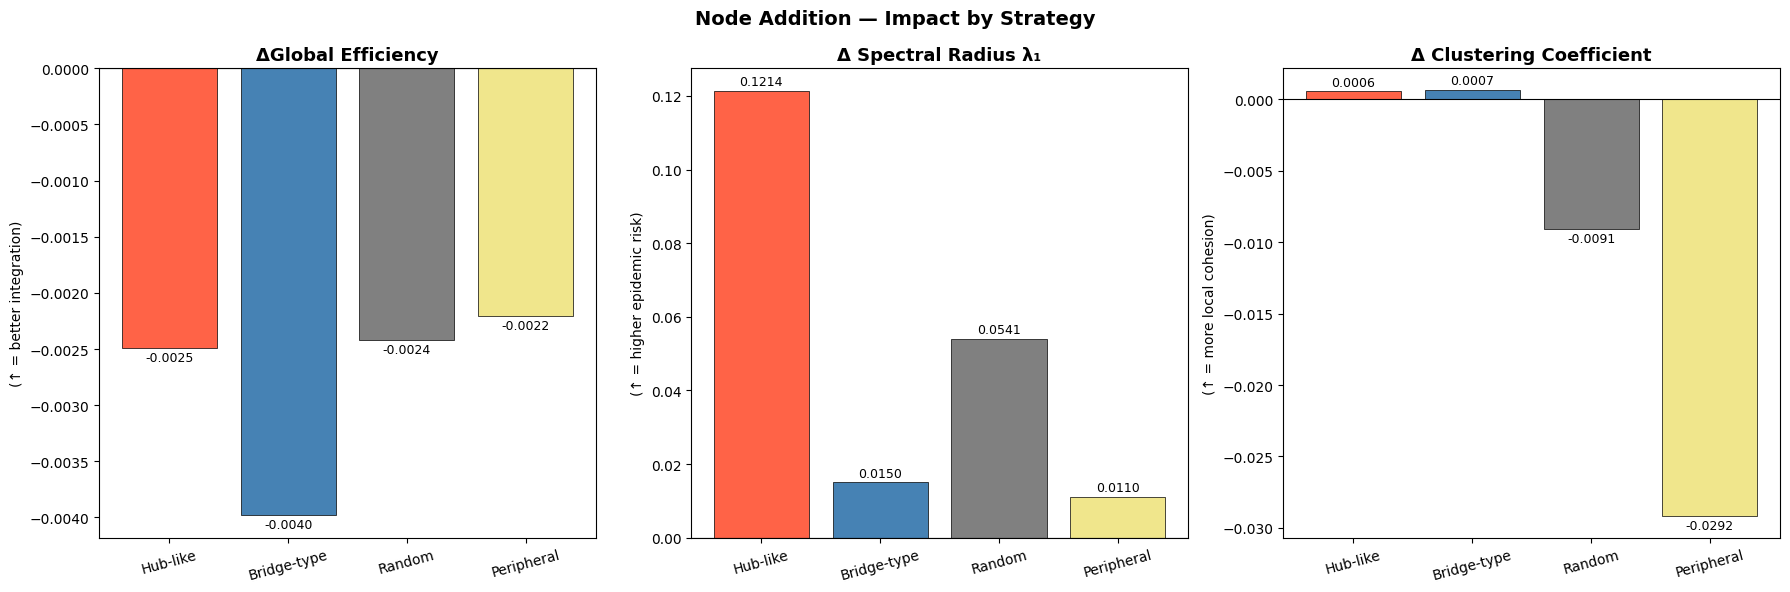

In [21]:
# ── Visualize addition impact ──────────────────────────────────────────────────
add_colors = {'Hub-like': 'tomato', 'Bridge-type': 'steelblue',
              'Random': 'gray',     'Peripheral': 'khaki'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_add = [
    ('ΔGlobal_Eff',  'ΔGlobal Efficiency\n(↑ = better integration)'),
    ('Δλ₁',         'Δ Spectral Radius λ₁\n(↑ = higher epidemic risk)'),
    ('ΔClustering',  'Δ Clustering Coefficient\n(↑ = more local cohesion)'),
]

for ax, (col, ylabel) in zip(axes, metrics_add):
    bars = ax.bar(add_df['Strategy'], add_df[col],
                  color=[add_colors[s] for s in add_df['Strategy']],
                  edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=2)
    ax.set_title(ylabel.split('\n')[0], fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel.split('\n')[1])
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Node Addition — Impact by Strategy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_node_addition.png', dpi=150, bbox_inches='tight')
plt.show()

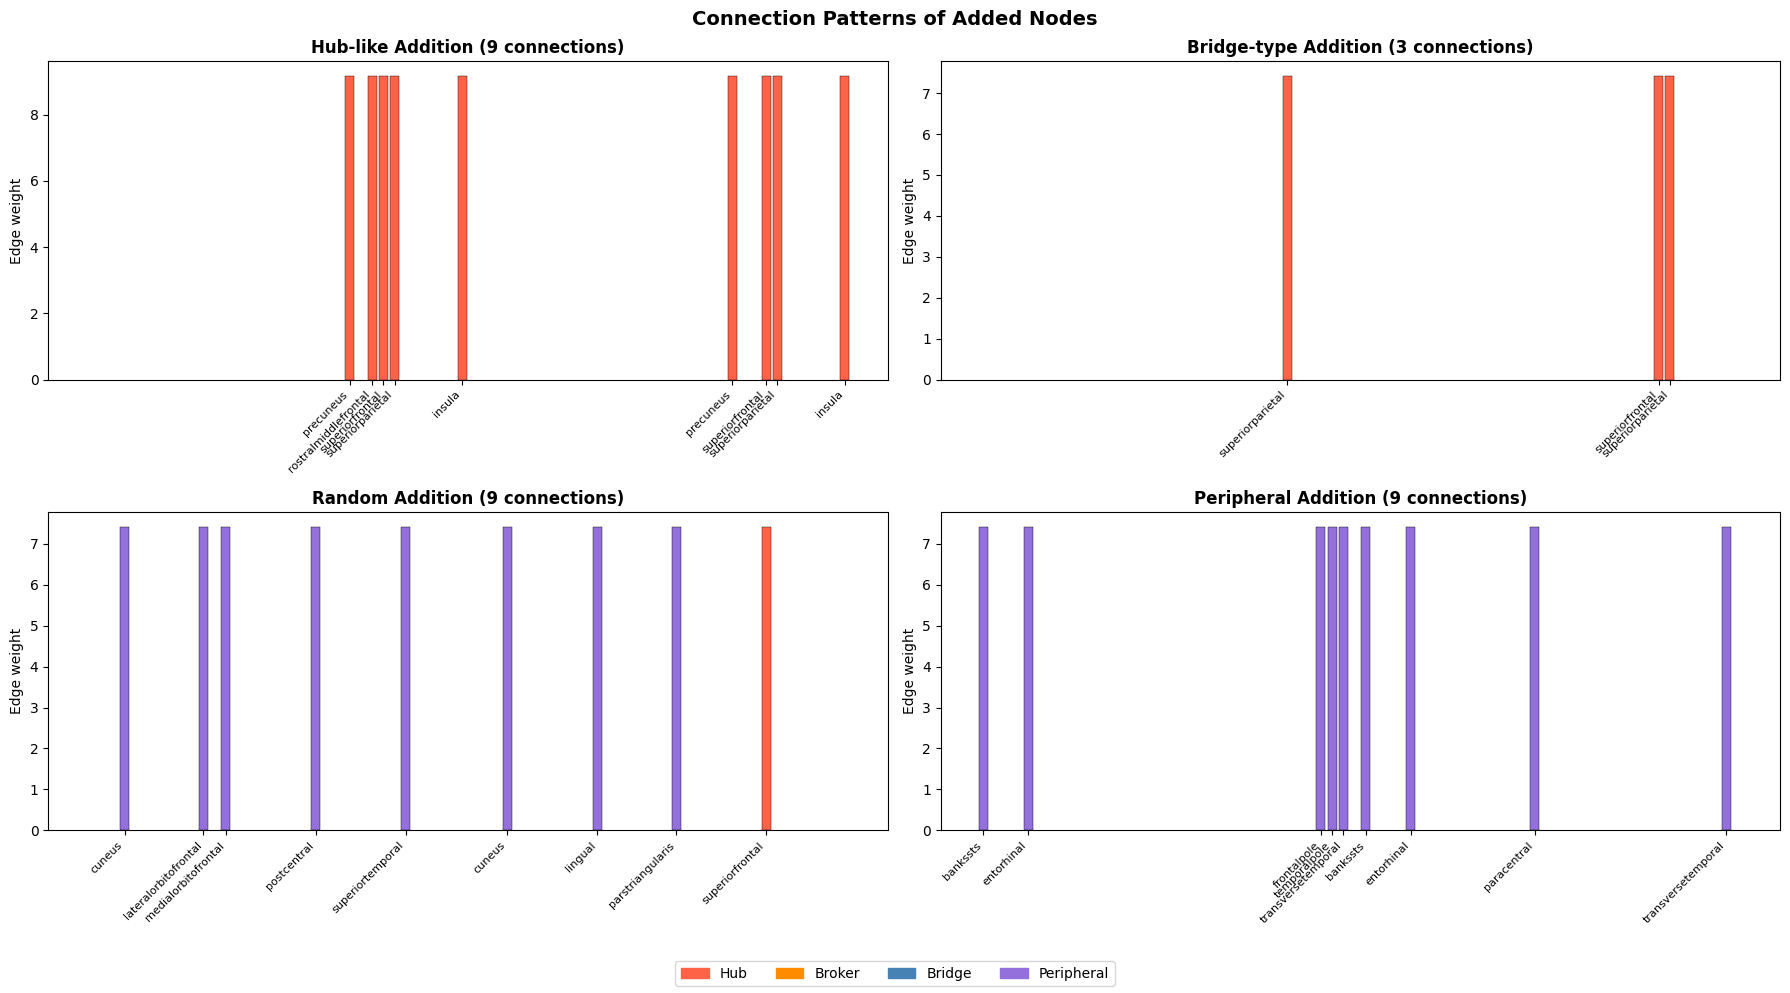

In [22]:

# ── Connection pattern of each added node ─────────────────────────────────────
from matplotlib.patches import Patch

def role_colors_fn(i):
    if i in hub_nodes:    return 'tomato'
    if i in broker_nodes: return 'darkorange'
    if i in bridge_nodes: return 'steelblue'
    return 'mediumpurple'

short_labels = [l.replace('L_', '').replace('R_', '') for l in sc_ctx_labels]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, _, w_new) in zip(axes, additions):
    connected = np.where(w_new > 0)[0]
    ax.bar(range(n), w_new, color='lightgray', edgecolor='none')
    ax.bar(connected, w_new[connected],
           color=[role_colors_fn(i) for i in connected], edgecolor='k', linewidth=0.3)
    ax.set_xticks(connected)
    ax.set_xticklabels([short_labels[i] for i in connected], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{name} Addition ({len(connected)} connections)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Edge weight')

legend_handles = [Patch(color='tomato',       label='Hub'),
                  Patch(color='darkorange',    label='Broker'),
                  Patch(color='steelblue',     label='Bridge'),
                  Patch(color='mediumpurple',  label='Peripheral')]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10, frameon=True)

plt.suptitle('Connection Patterns of Added Nodes', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('hcp_addition_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3: Cascade Failure Simulation

A **cascade failure** models how the removal of one node can trigger secondary failures in its neighbours — simulating neurological events like stroke, where initial lesion causes downstream deafferentation.

**Rules:**
1. Remove seed node
2. Neighbours whose degree drops below threshold `k_min` are also removed (deafferented)
3. Repeat until stable

We seed the cascade from hubs, brokers, bridges, and random nodes.

In [23]:
# ── Cascade failure ────────────────────────────────────────────────────────────
def cascade_failure(A, seed_node, k_min=2):
    """
    Remove seed_node, then iteratively remove any node whose degree
    falls below k_min. Returns list of removed nodes and final metrics.
    """
    A_curr = A.copy()
    n_curr = A_curr.shape[0]
    active = list(range(n_curr))
    removed = [seed_node]
    active.remove(seed_node)
    A_curr[seed_node, :] = 0
    A_curr[:, seed_node] = 0

    changed = True
    while changed:
        changed = False
        degrees = (A_curr[np.ix_(active, active)] > 0).sum(axis=1)
        to_remove = [active[i] for i, d in enumerate(degrees) if d < k_min]
        for node in to_remove:
            if node in active:
                active.remove(node)
                removed.append(node)
                A_curr[node, :] = 0
                A_curr[:, node] = 0
                changed = True

    sub = A_curr[np.ix_(active, active)]
    m   = network_metrics(sub) if len(active) > 2 else {'lcc_size': 0, 'global_eff': 0, 'lambda1': 0}
    return removed, active, m

# Run cascade from each key node type
k_min = 3   # minimum degree to survive
cascade_records = []

# Sample: top hub, top broker, top bridge, random node
seeds = [
    ('Hub',     hub_nodes[np.argmax(strength[hub_nodes])]),
    ('Broker',  broker_nodes[np.argmax(betweenness[broker_nodes])] if len(broker_nodes) > 0 else hub_nodes[1]),
    ('Bridge',  bridge_nodes[np.argmax(betweenness[bridge_nodes])] if len(bridge_nodes) > 0 else hub_nodes[2]),
    ('Random',  np.random.randint(0, n)),
]

for role, seed in seeds:
    removed, active, m = cascade_failure(sc_ctx, seed, k_min=k_min)
    cascade_records.append({
        'Seed Region'     : sc_ctx_labels[seed],
        'Seed Role'       : role,
        'Total Removed'   : len(removed),
        'Cascade Size'    : len(removed) - 1,   # secondary failures only
        'Remaining Nodes' : len(active),
        '% Network Lost'  : len(removed) / n * 100,
        'Final LCC'       : m.get('lcc_size', 0),
        'Final Global Eff': m.get('global_eff', 0),
        'Removed Regions' : [sc_ctx_labels[r] for r in removed[1:]],  # exclude seed
    })

cascade_df = pd.DataFrame(cascade_records)
print(f'Cascade failure simulation (k_min = {k_min})')
print(cascade_df[['Seed Region','Seed Role','Total Removed','Cascade Size','% Network Lost','Final LCC']].to_string(index=False))
print()
for _, row in cascade_df.iterrows():
    print(f"{row['Seed Role']} seed ({row['Seed Region']}) → secondary failures: {row['Removed Regions']}")

Cascade failure simulation (k_min = 3)
           Seed Region Seed Role  Total Removed  Cascade Size  % Network Lost  Final LCC
    R_superiorparietal       Hub              1             0        1.470588        1.0
L_rostralmiddlefrontal    Broker              1             0        1.470588        1.0
     L_superiorfrontal    Bridge              1             0        1.470588        1.0
 R_medialorbitofrontal    Random              1             0        1.470588        1.0

Hub seed (R_superiorparietal) → secondary failures: []
Broker seed (L_rostralmiddlefrontal) → secondary failures: []
Bridge seed (L_superiorfrontal) → secondary failures: []
Random seed (R_medialorbitofrontal) → secondary failures: []


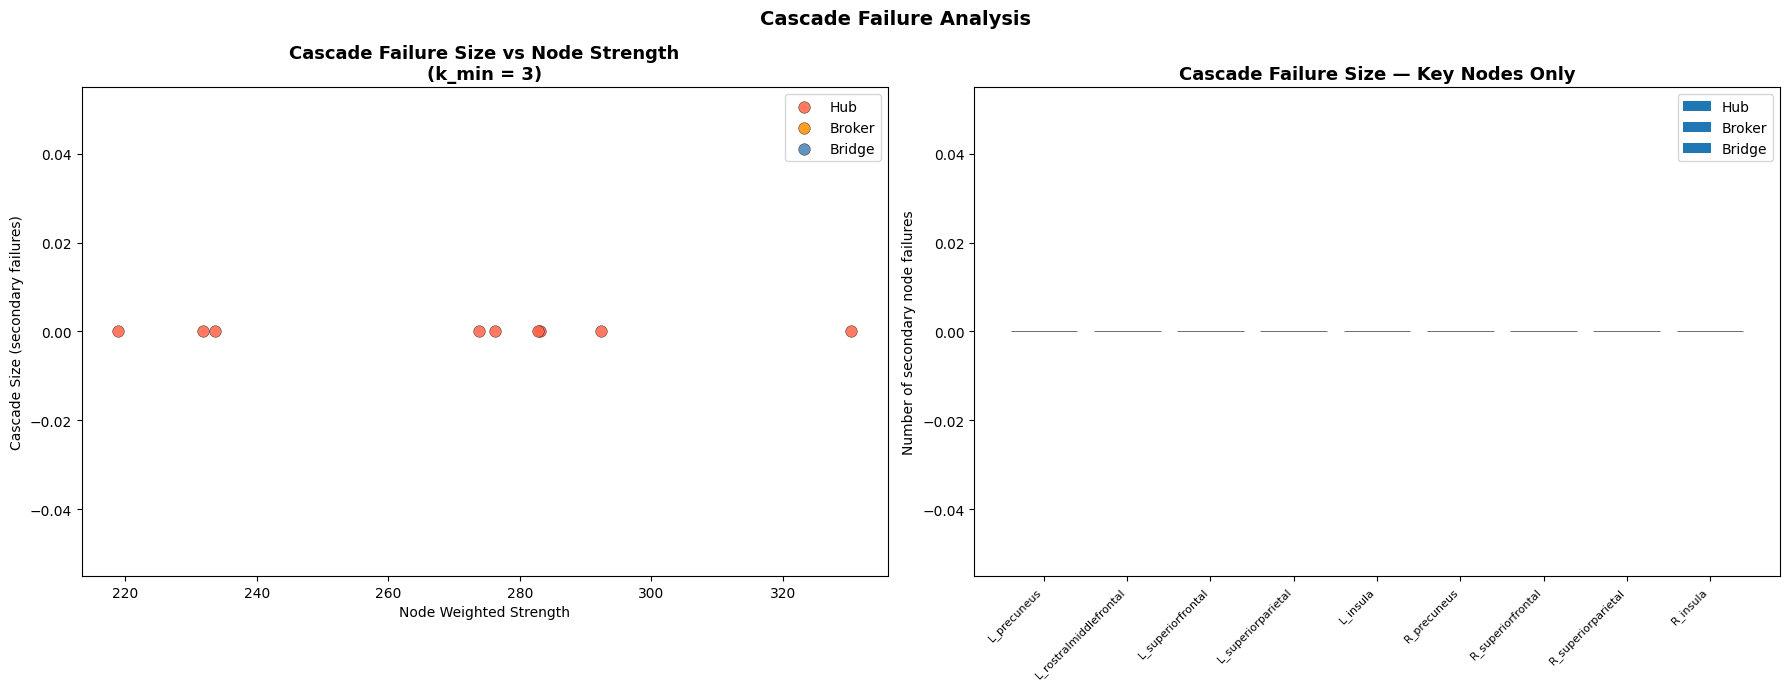

In [24]:
# ── Cascade size across ALL nodes ─────────────────────────────────────────────
all_cascade = []
for i in range(n):
    removed, active, _ = cascade_failure(sc_ctx, i, k_min=k_min)
    role = ('Hub' if i in hub_nodes else
            'Broker' if i in broker_nodes else
            'Bridge' if i in bridge_nodes else 'Peripheral')
    all_cascade.append({
        'node': i, 'region': sc_ctx_labels[i], 'role': role,
        'cascade_size': len(removed) - 1,
        'strength': strength[i], 'betweenness': betweenness[i],
    })
cascade_all_df = pd.DataFrame(all_cascade)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: strength vs cascade size
for role, color in role_colors.items():
    sub = cascade_all_df[cascade_all_df['role'] == role]
    axes[0].scatter(sub['strength'], sub['cascade_size'], c=color, s=70,
                    label=role, edgecolors='k', linewidths=0.3, alpha=0.85)
for _, row in cascade_all_df[cascade_all_df['cascade_size'] > 0].iterrows():
    axes[0].annotate(row['region'], (row['strength'], row['cascade_size']),
                     fontsize=7, xytext=(3, 2), textcoords='offset points')
axes[0].set_xlabel('Node Weighted Strength')
axes[0].set_ylabel('Cascade Size (secondary failures)')
axes[0].set_title(f'Cascade Failure Size vs Node Strength\n(k_min = {k_min})', fontsize=13, fontweight='bold')
axes[0].legend()

# Bar: cascade size per key node
key_cascade = cascade_all_df[cascade_all_df['role'] != 'Peripheral'].sort_values('cascade_size', ascending=False)
colors_bar = [role_colors[r] for r in key_cascade['role']]
axes[1].bar(range(len(key_cascade)), key_cascade['cascade_size'], color=colors_bar, edgecolor='k', linewidth=0.4)
axes[1].set_xticks(range(len(key_cascade)))
axes[1].set_xticklabels(key_cascade['region'], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Cascade Failure Size — Key Nodes Only', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of secondary node failures')
for role, color in role_colors.items():
    axes[1].bar([], [], color=color, label=role)
axes[1].legend()

plt.suptitle('Cascade Failure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_cascade_failure.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Before vs After Summary

──────────────────────────────────────────────────────────────────────────
Most damaging removal : R_superiorparietal (Hub)
  ΔGlobal Eff = -0.00715
  Δλ₁        = -1.0164

Most beneficial addition: Peripheral node
  ΔGlobal Eff = -0.00220
  Δλ₁        = 0.0110
──────────────────────────────────────────────────────────────────────────


/tmp/ipykernel_28871/2757810509.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'Hub\ntargeted':    np.trapz(df_hub['lcc_size'],    df_hub['frac_removed']),
/tmp/ipykernel_28871/2757810509.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'Broker\ntargeted': np.trapz(df_broker['lcc_size'], df_broker['frac_removed']),
/tmp/ipykernel_28871/2757810509.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'Bridge\ntargeted': np.trapz(df_bridge['lcc_size'], df_bridge['frac_removed']),
/tmp/ipykernel_28871/2757810509.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'Random':           np.trapz(df_rand['lcc_size'],   df_

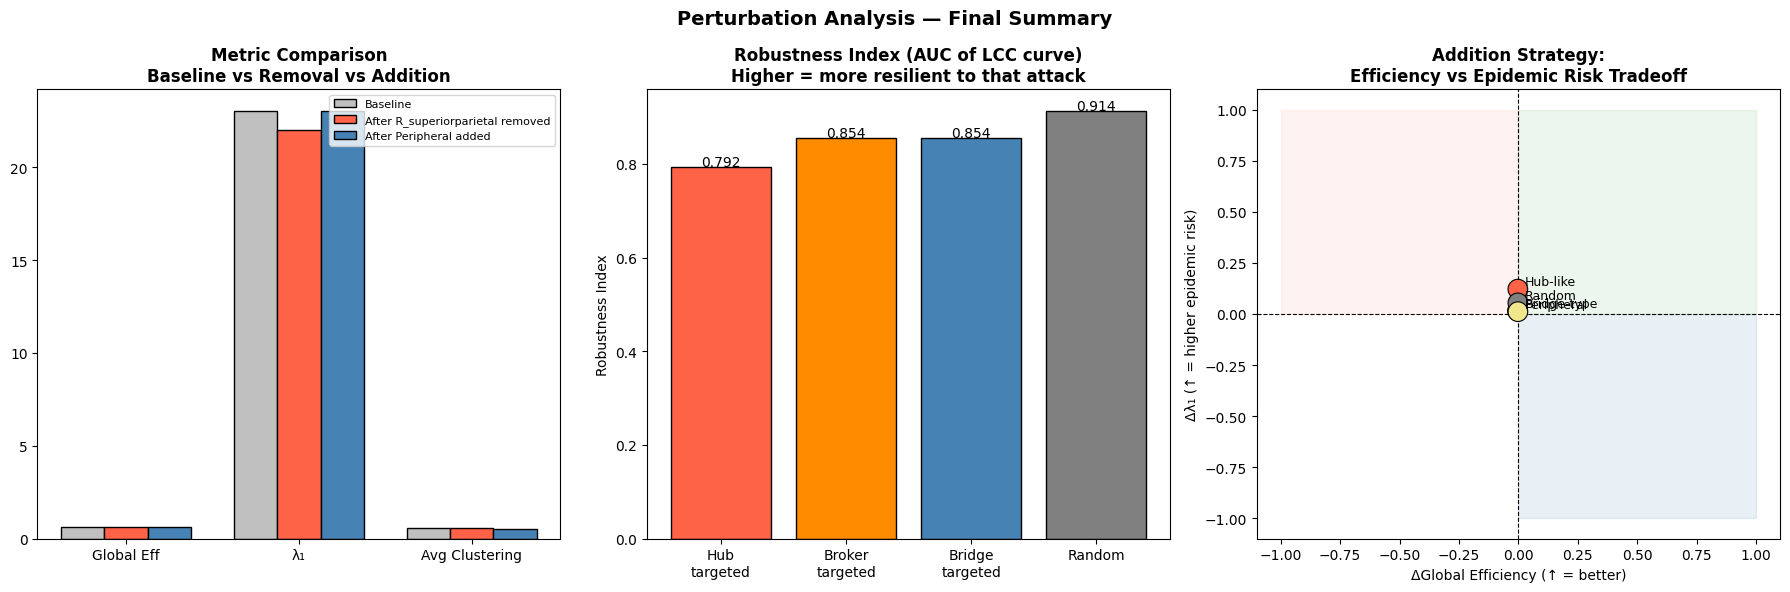

In [25]:
# ── Before / After table: best removal vs best addition ───────────────────────
# Find the most damaging removal and most beneficial addition
worst_removal = delta_df.loc[delta_df['ΔGlobal_Eff'].idxmin()]
best_addition = add_df.loc[add_df['ΔGlobal_Eff'].idxmax()]

print('──────────────────────────────────────────────────────────────────────────')
print(f'Most damaging removal : {worst_removal["Region"]} ({worst_removal["Role"]})')
print(f'  ΔGlobal Eff = {worst_removal["ΔGlobal_Eff"]:.5f}')
print(f'  Δλ₁        = {worst_removal["Δλ₁"]:.4f}')
print()
print(f'Most beneficial addition: {best_addition["Strategy"]} node')
print(f'  ΔGlobal Eff = {best_addition["ΔGlobal_Eff"]:.5f}')
print(f'  Δλ₁        = {best_addition["Δλ₁"]:.4f}')
print('──────────────────────────────────────────────────────────────────────────')

# ── Dashboard plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Metric comparison table
metric_labels = ['Global Eff', 'λ₁', 'Avg Clustering']
baseline_vals = [baseline['global_eff'], baseline['lambda1'], baseline['avg_clustering']]

# After worst removal
remaining_wr = [i for i in range(n) if sc_ctx_labels[i] != worst_removal['Region']]
sub_wr = sc_ctx[np.ix_(remaining_wr, remaining_wr)]
m_wr = network_metrics(sub_wr)
removal_vals = [m_wr['global_eff'], m_wr['lambda1'], m_wr['avg_clustering']]

# After best addition
A_best = dict(zip([s for s, _, _ in additions], [A for _, A, _ in additions]))[best_addition['Strategy']]
m_ba = network_metrics(A_best)
addition_vals = [m_ba['global_eff'], m_ba['lambda1'], m_ba['avg_clustering']]

x = np.arange(len(metric_labels))
w = 0.25
axes[0].bar(x - w, baseline_vals, w, label='Baseline', color='silver', edgecolor='k')
axes[0].bar(x,     removal_vals,  w, label=f'After {worst_removal["Region"]} removed', color='tomato', edgecolor='k')
axes[0].bar(x + w, addition_vals, w, label=f'After {best_addition["Strategy"]} added', color='steelblue', edgecolor='k')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_title('Metric Comparison\nBaseline vs Removal vs Addition', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2: Removal strategy robustness index
rob_data = {
    'Hub\ntargeted':    np.trapz(df_hub['lcc_size'],    df_hub['frac_removed']),
    'Broker\ntargeted': np.trapz(df_broker['lcc_size'], df_broker['frac_removed']),
    'Bridge\ntargeted': np.trapz(df_bridge['lcc_size'], df_bridge['frac_removed']),
    'Random':           np.trapz(df_rand['lcc_size'],   df_rand['frac_removed']),
}
axes[1].bar(rob_data.keys(), rob_data.values(),
            color=['tomato','darkorange','steelblue','gray'], edgecolor='k')
axes[1].set_title('Robustness Index (AUC of LCC curve)\nHigher = more resilient to that attack', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Robustness Index')
for i, (k, v) in enumerate(rob_data.items()):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)

# Panel 3: Addition strategy efficiency vs epidemic risk
axes[2].scatter(add_df['ΔGlobal_Eff'], add_df['Δλ₁'],
                c=[add_colors[s] for s in add_df['Strategy']], s=200,
                edgecolors='k', linewidths=0.8, zorder=3)
for _, row in add_df.iterrows():
    axes[2].annotate(row['Strategy'], (row['ΔGlobal_Eff'], row['Δλ₁']),
                     fontsize=9, xytext=(5, 3), textcoords='offset points')
axes[2].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[2].axvline(0, color='k', linewidth=0.8, linestyle='--')
axes[2].set_xlabel('ΔGlobal Efficiency (↑ = better)')
axes[2].set_ylabel('Δλ₁ (↑ = higher epidemic risk)')
axes[2].set_title('Addition Strategy:\nEfficiency vs Epidemic Risk Tradeoff', fontsize=12, fontweight='bold')
# Shade quadrants
axes[2].fill_between([-1,0],[0,0],[1,1], alpha=0.07, color='tomato')    # bad: low eff, high risk
axes[2].fill_between([0,1], [0,0],[1,1], alpha=0.07, color='green')     # good: high eff, high risk
axes[2].fill_between([0,1], [-1,-1],[0,0], alpha=0.12, color='steelblue')# ideal: high eff, low risk

plt.suptitle('Perturbation Analysis — Final Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_perturbation_summary.png', dpi=150, bbox_inches='tight')
plt.show()